<a href="https://colab.research.google.com/github/Hiraeth-mist/aging-muscle-transcriptomics-case-study/blob/main/notebooks/06_cross_muscle_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cross-Muscle Aging Comparison

## Objective

This notebook integrates differential expression and functional enrichment analyses across three skeletal muscle types:

- EDL (Extensor Digitorum Longus)
- Soleus
- TA (Tibialis Anterior)

The goal is to identify:

- Differences in aging-associated transcriptional responses
- Shared biological processes
- Muscle-specific aging signatures
- Relative susceptibility to aging

## Biological Questions

1. Which muscle exhibits the strongest aging-associated transcriptional remodeling?
2. Which pathways are shared across muscles?
3. Which pathways are unique to each muscle?
4. Can we build a biological model of muscle aging based on transcriptomic data?

## Deliverables

### Figure 16
Differentially Expressed Gene Counts Across Muscles

### Figure 17
Top Enriched Biological Processes Across Muscles

### Figure 18
Cross-Muscle Aging Summary Heatmap

### Table 3
Muscle Aging Summary Table

### Final Outcome

A comparative model describing how different skeletal muscles respond to aging.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
system("pip install -q rpy2")

['/bin/bash: line 1: pip install -q rpy2: command not found']

In [1]:
install.packages(c(
  "ggplot2",
  "dplyr",
  "tidyr",
  "readr",
  "pheatmap"
))

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [2]:
library(ggplot2)
library(dplyr)
library(tidyr)
library(readr)
library(pheatmap)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [3]:
edl_go <- read.csv(
"/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/results/enrichment/EDL_GO_BP.csv"
)

sol_go <- read.csv(
"/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/results/enrichment/Soleus_GO_BP.csv"
)

ta_go <- read.csv(
"/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/results/enrichment/TA_GO_BP.csv"
)

In [4]:
summary_table <- data.frame(
  Muscle = c("EDL","Soleus","TA"),
  Significant_Genes = c(1129,44,105),
  Upregulated = c(204,29,53),
  Downregulated = c(226,11,15),
  Enriched_Pathways = c(
    nrow(edl_go),
    nrow(sol_go),
    nrow(ta_go)
  )
)

summary_table

Muscle,Significant_Genes,Upregulated,Downregulated,Enriched_Pathways
<chr>,<dbl>,<dbl>,<dbl>,<int>
EDL,1129,204,226,89
Soleus,44,29,11,13
TA,105,53,15,15


In [5]:
write.csv(
summary_table,
"/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/results/tables/Muscle_Aging_Summary.csv",
row.names = FALSE
)

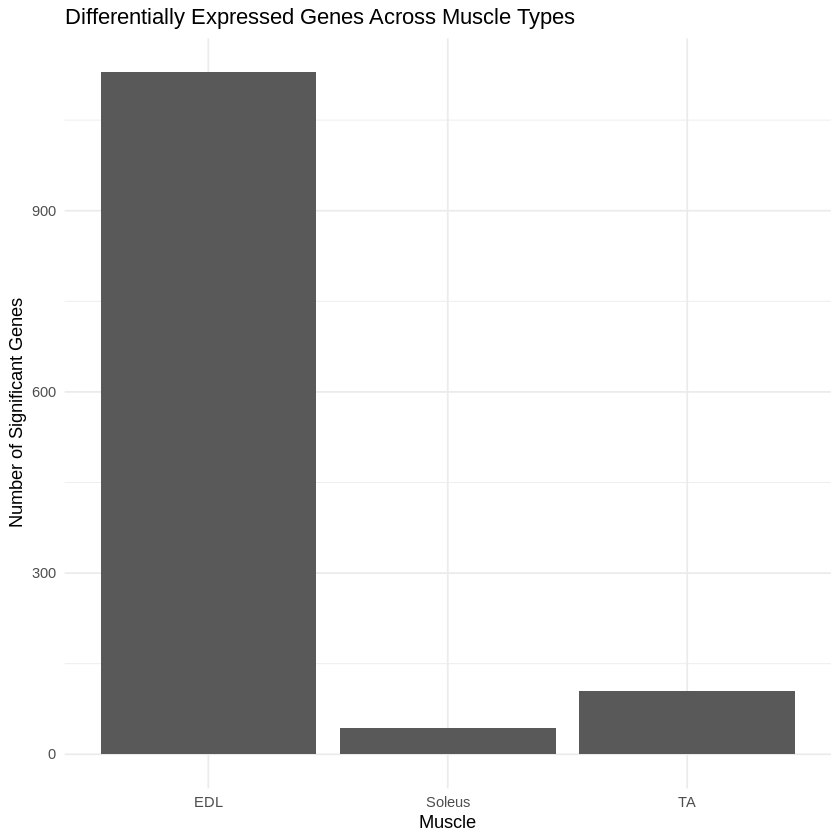

In [6]:
deg_counts <- data.frame(
  Muscle = c("EDL","Soleus","TA"),
  Significant_Genes = c(1129,44,105)
)

ggplot(
  deg_counts,
  aes(
    x = Muscle,
    y = Significant_Genes
  )
) +
  geom_col() +
  labs(
    title = "Differentially Expressed Genes Across Muscle Types",
    y = "Number of Significant Genes"
  ) +
  theme_minimal()

In [11]:
ggsave(
"/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/results/comparison/DEG_comparison.pdf",
width = 8,
height = 6
)

In [12]:
top_edl <- edl_go %>%
  select(Description,p.adjust) %>%
  head(5)

top_edl$Muscle <- "EDL"

top_sol <- sol_go %>%
  select(Description,p.adjust) %>%
  head(5)

top_sol$Muscle <- "Soleus"

top_ta <- ta_go %>%
  select(Description,p.adjust) %>%
  head(5)

top_ta$Muscle <- "TA"

top_pathways <- bind_rows(
  top_edl,
  top_sol,
  top_ta
)

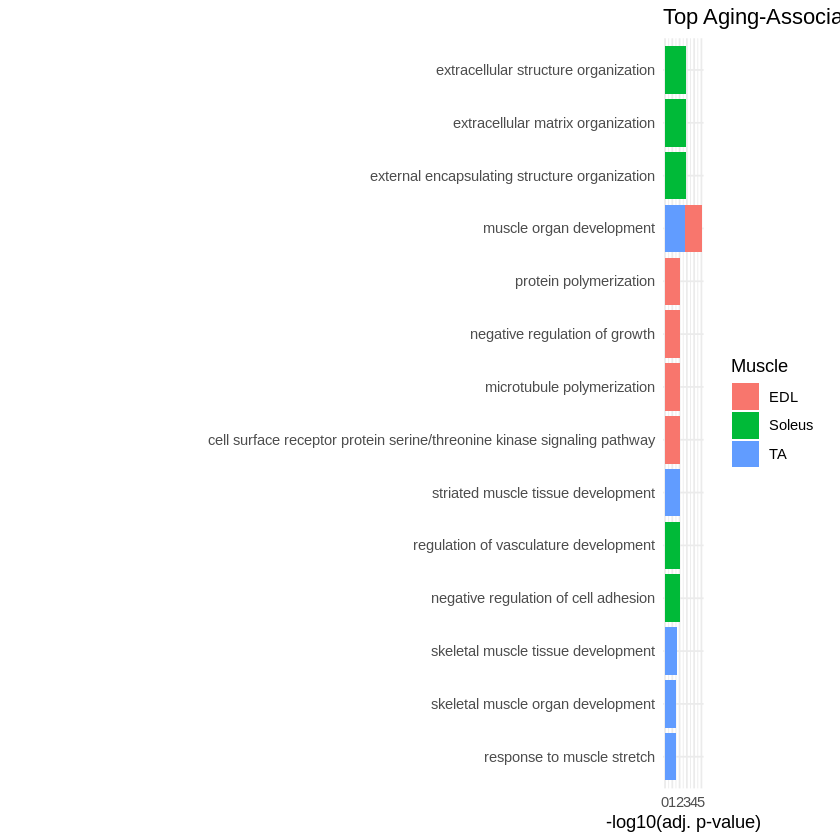

In [13]:
ggplot(
  top_pathways,
  aes(
    x = reorder(
      Description,
      -log10(p.adjust)
    ),
    y = -log10(p.adjust),
    fill = Muscle
  )
) +
  geom_col() +
  coord_flip() +
  theme_minimal() +
  labs(
    title = "Top Aging-Associated Biological Processes",
    x = "",
    y = "-log10(adj. p-value)"
  )

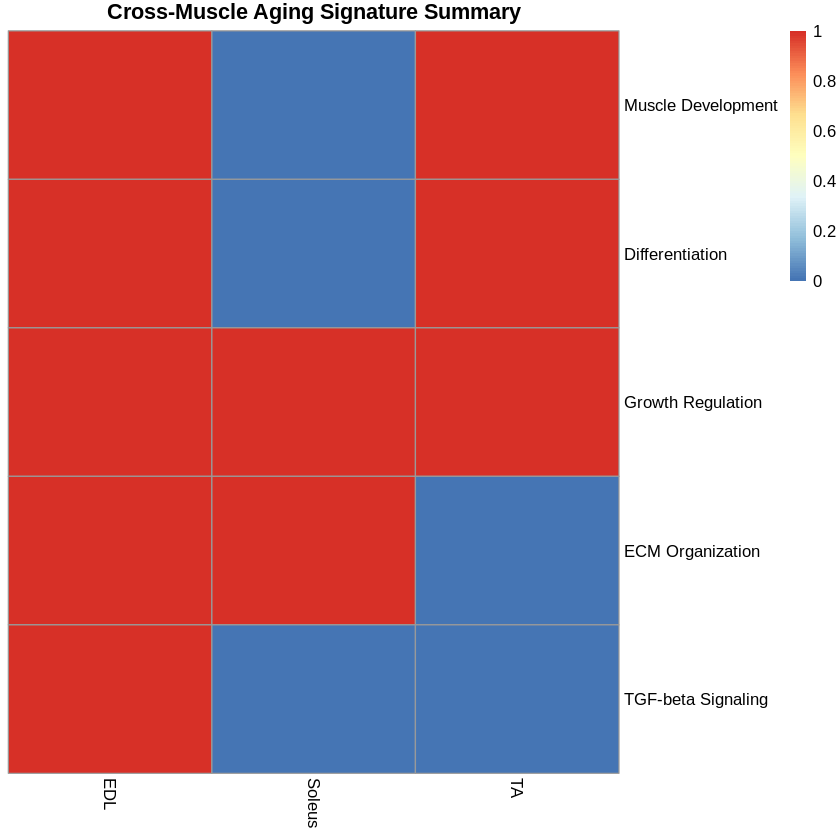

In [14]:
pathway_matrix <- matrix(
c(
1,0,1,
1,0,1,
1,1,1,
1,1,0,
1,0,0
),
nrow=5,
byrow=TRUE
)

rownames(pathway_matrix) <- c(
"Muscle Development",
"Differentiation",
"Growth Regulation",
"ECM Organization",
"TGF-beta Signaling"
)

colnames(pathway_matrix) <- c(
"EDL",
"Soleus",
"TA"
)

pheatmap(
pathway_matrix,
cluster_rows = FALSE,
cluster_cols = FALSE,
main = "Cross-Muscle Aging Signature Summary"
)

## Key Findings

### EDL

EDL exhibited the strongest aging-associated transcriptomic remodeling, showing the highest number of differentially expressed genes and enriched biological pathways.

### Soleus

Soleus displayed relatively limited transcriptional disruption, with enrichment focused on extracellular matrix organization and vascular processes.

### TA

TA maintained strong muscle-specific developmental and adaptive pathways despite aging.

### Overall Conclusion

Aging affects skeletal muscles in a muscle-type-specific manner.

The EDL muscle appears most susceptible to aging-associated transcriptional remodeling, whereas Soleus exhibits relative resilience and TA demonstrates an intermediate phenotype.

These findings highlight distinct biological strategies of adaptation and degeneration across skeletal muscle types.